In [2]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("ultralytics") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "ultralytics"])

In [ ]:
import os
import random
import shutil
import zipfile
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yaml
from PIL import Image, ImageDraw
from ultralytics import YOLO

SEED = 993
NUM_CLASSES = 52

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

REPO_ROOT = Path.cwd()
WORK_DIR = REPO_ROOT / "solution_workdir"
RAW_DIR = WORK_DIR / "raw"
DATA_DIR = WORK_DIR / "data"
NORMALIZED_DIR = DATA_DIR / "normalized"
META_DIR = WORK_DIR / "meta"
SPLITS_DIR = WORK_DIR / "splits"
RUNS_DIR = WORK_DIR / "runs"
WEIGHTS_DIR = WORK_DIR / "weights"

if WORK_DIR.exists():
    shutil.rmtree(WORK_DIR)

for path in [RAW_DIR, DATA_DIR, NORMALIZED_DIR, META_DIR, SPLITS_DIR, RUNS_DIR, WEIGHTS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print("REPO_ROOT:", REPO_ROOT)
print("WORK_DIR:", WORK_DIR)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

REPO_ROOT: /Users/ariyter-oganezov/Documents/DL
WORK_DIR: /Users/ariyter-oganezov/Documents/DL/solution_workdir
CUDA available: False


In [4]:
def extract_zip(zip_path, dst_dir):
    dst_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(dst_dir)


zip_paths = sorted(path for path in REPO_ROOT.glob("*.zip") if path.is_file())
print("root zip files:", [path.name for path in zip_paths])
assert zip_paths, "В корне репозитория должен лежать хотя бы один zip-архив с данными"

for zip_path in zip_paths:
    extract_zip(zip_path, RAW_DIR / zip_path.stem)

for _ in range(3):
    nested_zips = sorted(RAW_DIR.rglob("*.zip"))
    new_zips = [path for path in nested_zips if not (path.parent / path.stem).exists()]
    if not new_zips:
        break
    for zip_path in new_zips:
        extract_zip(zip_path, zip_path.parent / zip_path.stem)

print("extracted top-level:")
for path in sorted(RAW_DIR.iterdir()):
    print(" ", path)

root zip files: ['2026-cv-competition.zip']
extracted top-level:
  /Users/ariyter-oganezov/Documents/DL/solution_workdir/raw/2026-cv-competition


In [5]:
def is_inside(path, parent):
    try:
        path.resolve().relative_to(parent.resolve())
        return True
    except ValueError:
        return False


def allowed_candidate(path):
    parts = {part.lower() for part in path.parts}
    if "competition_workdir" in parts:
        return False
    if is_inside(path, WORK_DIR) and not is_inside(path, RAW_DIR):
        return False
    return True


def find_first_file(filename):
    candidates = []
    for base in [REPO_ROOT, RAW_DIR]:
        candidates.extend(base.rglob(filename))

    candidates = [path for path in candidates if allowed_candidate(path)]
    candidates = sorted(set(candidates), key=lambda p: (0 if p.parent == REPO_ROOT else 1, len(p.parts), str(p)))
    assert candidates, f"Не найден файл {filename}"
    return candidates[0]


def all_candidate_dirs():
    dirs = []
    for base in [REPO_ROOT, RAW_DIR]:
        if base.exists():
            dirs.append(base)
            dirs.extend(path for path in base.rglob("*") if path.is_dir())
    return sorted(set(path for path in dirs if allowed_candidate(path)), key=lambda p: (len(p.parts), str(p)))


def has_file_with_suffix(path, suffixes):
    suffixes = {suffix.lower() for suffix in suffixes}
    return any(child.is_file() and child.suffix.lower() in suffixes for child in path.iterdir())


def find_images_dir(split_name):
    split_name = split_name.lower()
    candidates = []

    for path in all_candidate_dirs():
        parts = [part.lower() for part in path.parts]
        if path.name.lower() != "images":
            continue
        if split_name not in parts:
            continue
        if split_name == "train" and "test" in parts:
            continue
        if split_name == "test" and "train" in parts:
            continue
        if has_file_with_suffix(path, IMAGE_EXTENSIONS):
            candidates.append(path)

    candidates = sorted(candidates, key=lambda p: (len(p.parts), str(p)))
    assert candidates, f"Не найдена папка {split_name}/images"
    return candidates[0]


def find_labels_dir():
    candidates = []

    for path in all_candidate_dirs():
        parts = [part.lower() for part in path.parts]
        if path.name.lower() != "labels":
            continue
        if "train" not in parts or "test" in parts:
            continue
        if has_file_with_suffix(path, {".txt"}):
            candidates.append(path)

    candidates = sorted(candidates, key=lambda p: (len(p.parts), str(p)))
    assert candidates, "Не найдена папка train/labels"
    return candidates[0]


IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

SAMPLE_PATH = find_first_file("sample_submission.csv")
src_train_images = find_images_dir("train")
src_train_labels = find_labels_dir()
src_test_images = find_images_dir("test")

print("SAMPLE_PATH:", SAMPLE_PATH)
print("src_train_images:", src_train_images)
print("src_train_labels:", src_train_labels)
print("src_test_images:", src_test_images)

SAMPLE_PATH: /Users/ariyter-oganezov/Documents/DL/solution_workdir/raw/2026-cv-competition/sample_submission.csv
src_train_images: /Users/ariyter-oganezov/Documents/DL/solution_workdir/raw/2026-cv-competition/train/train/images
src_train_labels: /Users/ariyter-oganezov/Documents/DL/solution_workdir/raw/2026-cv-competition/train/train/labels
src_test_images: /Users/ariyter-oganezov/Documents/DL/solution_workdir/raw/2026-cv-competition/test/test/images


In [6]:
dst_train_images = NORMALIZED_DIR / "train" / "images"
dst_train_labels = NORMALIZED_DIR / "train" / "labels"
dst_test_images = NORMALIZED_DIR / "test" / "images"
dst_sample = NORMALIZED_DIR / "sample_submission.csv"

for path in [dst_train_images, dst_train_labels, dst_test_images]:
    path.mkdir(parents=True, exist_ok=True)

shutil.copy2(SAMPLE_PATH, dst_sample)

for src_dir, dst_dir in [
    (src_train_images, dst_train_images),
    (src_train_labels, dst_train_labels),
    (src_test_images, dst_test_images),
]:
    for src_path in sorted(src_dir.glob("*")):
        if src_path.is_file():
            shutil.copy2(src_path, dst_dir / src_path.name)

print("normalized train images:", len(list(dst_train_images.glob("*"))))
print("normalized train labels:", len(list(dst_train_labels.glob("*"))))
print("normalized test images:", len(list(dst_test_images.glob("*"))))
print("sample exists:", dst_sample.exists())

normalized train images: 1697
normalized train labels: 1697
normalized test images: 424
sample exists: True


In [7]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


def image_paths_in(path):
    return sorted(p for p in path.glob("*") if p.suffix.lower() in IMAGE_EXTENSIONS)


def read_label_file(label_path):
    rows = []
    with open(label_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            class_id, xc, yc, w, h = line.split()
            rows.append(
                {
                    "class_id": int(class_id),
                    "xc": float(xc),
                    "yc": float(yc),
                    "w": float(w),
                    "h": float(h),
                }
            )
    return rows


def yolo_to_xyxy(xc, yc, w, h, image_w, image_h):
    x1 = (xc - w / 2) * image_w
    y1 = (yc - h / 2) * image_h
    x2 = (xc + w / 2) * image_w
    y2 = (yc + h / 2) * image_h
    return x1, y1, x2, y2


train_image_paths = image_paths_in(dst_train_images)
test_image_paths = image_paths_in(dst_test_images)

image_rows = []
box_rows = []

for image_path in train_image_paths:
    label_path = dst_train_labels / f"{image_path.stem}.txt"
    assert label_path.exists(), f"Нет label-файла для {image_path.name}"

    with Image.open(image_path) as img:
        image_w, image_h = img.size

    labels = read_label_file(label_path)
    classes_in_image = sorted({row["class_id"] for row in labels})

    image_rows.append(
        {
            "image_name": image_path.name,
            "image_stem": image_path.stem,
            "image_path": str(image_path.resolve()),
            "label_path": str(label_path.resolve()),
            "image_w": image_w,
            "image_h": image_h,
            "num_boxes": len(labels),
            "classes_in_image": classes_in_image,
        }
    )

    for box_id, row in enumerate(labels):
        x1, y1, x2, y2 = yolo_to_xyxy(row["xc"], row["yc"], row["w"], row["h"], image_w, image_h)
        box_rows.append(
            {
                "image_name": image_path.name,
                "image_stem": image_path.stem,
                "box_id": box_id,
                "class_id": row["class_id"],
                "xc": row["xc"],
                "yc": row["yc"],
                "w": row["w"],
                "h": row["h"],
                "image_w": image_w,
                "image_h": image_h,
                "bbox_w_px": row["w"] * image_w,
                "bbox_h_px": row["h"] * image_h,
                "bbox_area_px": row["w"] * image_w * row["h"] * image_h,
                "x1": x1,
                "y1": y1,
                "x2": x2,
                "y2": y2,
            }
        )

images_df = pd.DataFrame(image_rows)
boxes_df = pd.DataFrame(box_rows)
test_df = pd.DataFrame({"image_name": [p.name for p in test_image_paths], "image_path": [str(p.resolve()) for p in test_image_paths]})
sample_df = pd.read_csv(dst_sample, keep_default_na=False)

print("Train images:", len(images_df))
print("Test images:", len(test_df))
print("Boxes:", len(boxes_df))
print("Classes:", boxes_df["class_id"].nunique())
print("Sample rows:", len(sample_df))

display(images_df.head())
display(boxes_df.head())
display(sample_df.head())

Train images: 1697
Test images: 424
Boxes: 10498
Classes: 52
Sample rows: 424


,image_name,image_stem,image_path,label_path,image_w,image_h,num_boxes,classes_in_image
0,IMG20240219113638_jpg.rf.ff06b9b93da9ca10600f9...,IMG20240219113638_jpg.rf.ff06b9b93da9ca10600f9...,/Users/ariyter-oganezov/Documents/DL/solution_...,/Users/ariyter-oganezov/Documents/DL/solution_...,640,640,11,"[16, 20, 34, 37, 45, 50]"
1,IMG20240219113649_jpg.rf.0aa36d5700345b509e0a4...,IMG20240219113649_jpg.rf.0aa36d5700345b509e0a4...,/Users/ariyter-oganezov/Documents/DL/solution_...,/Users/ariyter-oganezov/Documents/DL/solution_...,640,640,11,"[16, 20, 34, 37, 45, 50]"
2,IMG20240219113715_jpg.rf.a71fa6e6f4be2b70af832...,IMG20240219113715_jpg.rf.a71fa6e6f4be2b70af832...,/Users/ariyter-oganezov/Documents/DL/solution_...,/Users/ariyter-oganezov/Documents/DL/solution_...,640,640,11,"[16, 20, 34, 37, 45, 50]"
3,IMG20240219113726_jpg.rf.55744d06df6f9a980cafa...,IMG20240219113726_jpg.rf.55744d06df6f9a980cafa...,/Users/ariyter-oganezov/Documents/DL/solution_...,/Users/ariyter-oganezov/Documents/DL/solution_...,640,640,11,"[16, 20, 34, 37, 45, 50]"
4,IMG20240219113745_jpg.rf.06494033a07fb1bb98e68...,IMG20240219113745_jpg.rf.06494033a07fb1bb98e68...,/Users/ariyter-oganezov/Documents/DL/solution_...,/Users/ariyter-oganezov/Documents/DL/solution_...,640,640,10,"[6, 16, 20, 34, 37, 45]"


,image_name,image_stem,box_id,class_id,xc,yc,w,h,image_w,image_h,bbox_w_px,bbox_h_px,bbox_area_px,x1,y1,x2,y2
0,IMG20240219113638_jpg.rf.ff06b9b93da9ca10600f9...,IMG20240219113638_jpg.rf.ff06b9b93da9ca10600f9...,0,16,0.554688,0.312500,0.090625,0.071094,640,640,58.0,45.5,2639.00,326.00,177.25,384.00,222.75
1,IMG20240219113638_jpg.rf.ff06b9b93da9ca10600f9...,IMG20240219113638_jpg.rf.ff06b9b93da9ca10600f9...,1,16,0.632031,0.375781,0.096875,0.070312,640,640,62.0,45.0,2790.00,373.50,218.00,435.50,263.00
2,IMG20240219113638_jpg.rf.ff06b9b93da9ca10600f9...,IMG20240219113638_jpg.rf.ff06b9b93da9ca10600f9...,2,45,0.486719,0.614062,0.110156,0.088281,640,640,70.5,56.5,3983.25,276.25,364.75,346.75,421.25
3,IMG20240219113638_jpg.rf.ff06b9b93da9ca10600f9...,IMG20240219113638_jpg.rf.ff06b9b93da9ca10600f9...,3,20,0.492188,0.407813,0.135156,0.071094,640,640,86.5,45.5,3935.75,271.75,238.25,358.25,283.75
4,IMG20240219113638_jpg.rf.ff06b9b93da9ca10600f9...,IMG20240219113638_jpg.rf.ff06b9b93da9ca10600f9...,4,37,0.475781,0.495312,0.145313,0.101562,640,640,93.0,65.0,6045.00,258.00,284.50,351.00,349.50


,image_id,PredictionString
0,IMG20240228122809_jpg.rf.bb184f37aa98d96f1db1a...,
1,IMG20240228122949_jpg.rf.f763b523e7bb4e7250796...,
2,IMG20240228122955_jpg.rf.18d6c6ad9c8c69153da34...,
3,IMG20240228123115_jpg.rf.3b9ae83d0bc7242bafe52...,
4,IMG20240228123131_jpg.rf.84cf43cf1c7a8d09dc507...,


,class_id,num_boxes,mean_bbox_w_px,mean_bbox_h_px,mean_bbox_area_px,num_images
0,50,853,130.686401,148.541618,22035.443582,570
1,51,452,113.173119,136.513274,18057.816371,337
2,26,327,68.006116,79.618502,6266.225536,243
3,32,290,86.051724,78.256897,7065.437069,189
4,34,289,39.494810,44.240484,2255.065744,91
5,40,277,54.763538,60.355596,3989.984657,188
6,29,276,73.335145,96.711957,8072.475543,188
7,39,274,117.237226,109.509124,13077.199359,189
8,10,263,58.184411,78.222433,5280.778517,203
9,13,256,113.586914,116.580078,11624.769532,197


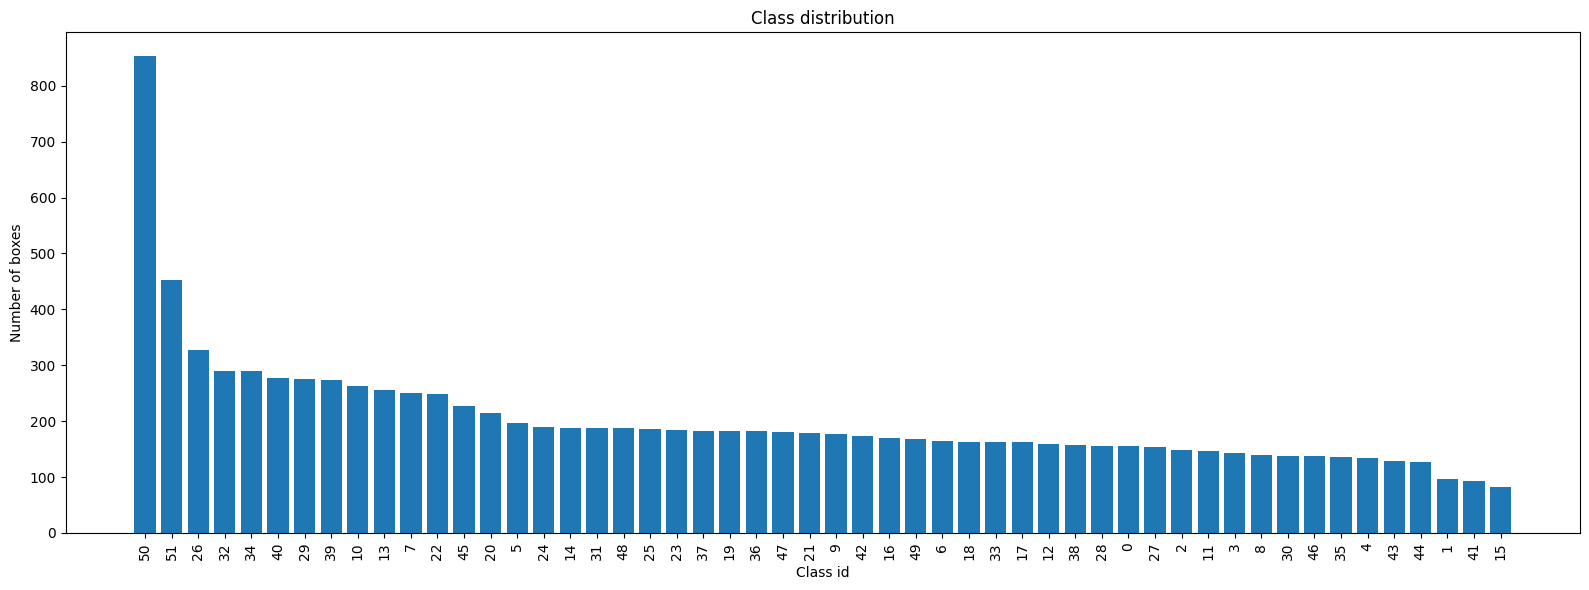

In [8]:
image_presence = defaultdict(int)
for classes in images_df["classes_in_image"]:
    for class_id in classes:
        image_presence[class_id] += 1

class_stats_df = (
    boxes_df.groupby("class_id")
    .agg(
        num_boxes=("class_id", "size"),
        mean_bbox_w_px=("bbox_w_px", "mean"),
        mean_bbox_h_px=("bbox_h_px", "mean"),
        mean_bbox_area_px=("bbox_area_px", "mean"),
    )
    .reset_index()
)
class_stats_df["num_images"] = class_stats_df["class_id"].map(image_presence)
class_stats_df = class_stats_df.sort_values("num_boxes", ascending=False).reset_index(drop=True)

images_df.to_csv(META_DIR / "train_images.csv", index=False)
boxes_df.to_csv(META_DIR / "train_boxes.csv", index=False)
test_df.to_csv(META_DIR / "test_images.csv", index=False)
class_stats_df.to_csv(META_DIR / "class_stats.csv", index=False)

display(class_stats_df.head(10))

plt.figure(figsize=(16, 6))
plt.bar(class_stats_df["class_id"].astype(str), class_stats_df["num_boxes"])
plt.xlabel("Class id")
plt.ylabel("Number of boxes")
plt.title("Class distribution")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [9]:
all_image_paths = images_df["image_path"].tolist()

train_txt = SPLITS_DIR / "train_images_all.txt"
val_txt = SPLITS_DIR / "val_images_all.txt"

train_txt.write_text("\n".join(all_image_paths) + "\n", encoding="utf-8")
val_txt.write_text("\n".join(all_image_paths) + "\n", encoding="utf-8")

dataset_yaml = {
    "path": str(NORMALIZED_DIR.resolve()),
    "train": str(train_txt.resolve()),
    "val": str(val_txt.resolve()),
    "names": {class_id: f"class_{class_id}" for class_id in range(NUM_CLASSES)},
}

yaml_path = WORK_DIR / "detector_dataset_all.yaml"
with open(yaml_path, "w", encoding="utf-8") as f:
    yaml.safe_dump(dataset_yaml, f, sort_keys=False, allow_unicode=True)

print(yaml_path)
print(yaml.safe_dump(dataset_yaml, sort_keys=False, allow_unicode=True)[:1000])

/Users/ariyter-oganezov/Documents/DL/solution_workdir/detector_dataset_all.yaml
path: /Users/ariyter-oganezov/Documents/DL/solution_workdir/data/normalized
train: /Users/ariyter-oganezov/Documents/DL/solution_workdir/splits/train_images_all.txt
val: /Users/ariyter-oganezov/Documents/DL/solution_workdir/splits/val_images_all.txt
names:
  0: class_0
  1: class_1
  2: class_2
  3: class_3
  4: class_4
  5: class_5
  6: class_6
  7: class_7
  8: class_8
  9: class_9
  10: class_10
  11: class_11
  12: class_12
  13: class_13
  14: class_14
  15: class_15
  16: class_16
  17: class_17
  18: class_18
  19: class_19
  20: class_20
  21: class_21
  22: class_22
  23: class_23
  24: class_24
  25: class_25
  26: class_26
  27: class_27
  28: class_28
  29: class_29
  30: class_30
  31: class_31
  32: class_32
  33: class_33
  34: class_34
  35: class_35
  36: class_36
  37: class_37
  38: class_38
  39: class_39
  40: class_40
  41: class_41
  42: class_42
  43: class_43
  44: class_44
  45: cl

In [10]:
MODEL_PATH = "yolo11l.pt"
TRAIN_EPOCHS = 50
IMG_SIZE = 640
BATCH_SIZE = 4
DEVICE = 0 if torch.cuda.is_available() else "cpu"
RUN_NAME = f"full_yolo11l_{IMG_SIZE}_e{TRAIN_EPOCHS}_seed{SEED}"

print("MODEL_PATH:", MODEL_PATH)
print("TRAIN_EPOCHS:", TRAIN_EPOCHS)
print("IMG_SIZE:", IMG_SIZE)
print("BATCH_SIZE:", BATCH_SIZE)
print("DEVICE:", DEVICE)
print("RUN_NAME:", RUN_NAME)

MODEL_PATH: yolo11l.pt
TRAIN_EPOCHS: 50
IMG_SIZE: 640
BATCH_SIZE: 4
DEVICE: cpu
RUN_NAME: full_yolo11l_640_e50_seed993


In [11]:
model = YOLO(MODEL_PATH)

train_results = model.train(
    data=str(yaml_path),
    epochs=TRAIN_EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    device=DEVICE,
    workers=2,
    project=str(RUNS_DIR),
    name=RUN_NAME,
    pretrained=True,
    seed=SEED,
    deterministic=True,
    patience=20,
    cos_lr=True,
    amp=True,
    cache=False,
    save_period=10,
    verbose=True,
)

print("train done")

New https://pypi.org/project/ultralytics/8.4.45 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.41 🚀 Python-3.11.7 torch-2.11.0 CPU (Apple M2 Pro)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/Users/ariyter-oganezov/Documents/DL/solution_workdir/detector_dataset_all.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11l.pt, momentum=0.937, mosa

KeyboardInterrupt: 

In [ ]:
def format_prediction_string_xyxy(result, conf_thr=0.001):
    if result.boxes is None or len(result.boxes) == 0:
        return ""

    boxes = result.boxes.xyxy.cpu().numpy()
    classes = result.boxes.cls.cpu().numpy().astype(int)
    confs = result.boxes.conf.cpu().numpy()

    keep = confs >= conf_thr
    boxes = boxes[keep]
    classes = classes[keep]
    confs = confs[keep]

    if len(boxes) == 0:
        return ""

    order = np.argsort(-confs)
    boxes = boxes[order]
    classes = classes[order]
    confs = confs[order]

    image_h, image_w = result.orig_shape

    parts = []
    for class_id, conf, box in zip(classes, confs, boxes):
        x1, y1, x2, y2 = box
        x1 = float(np.clip(x1, 0, image_w - 1))
        y1 = float(np.clip(y1, 0, image_h - 1))
        x2 = float(np.clip(x2, 0, image_w - 1))
        y2 = float(np.clip(y2, 0, image_h - 1))

        if x2 <= x1 or y2 <= y1:
            continue

        parts.extend([
            str(int(class_id)),
            f"{float(conf):.6f}",
            f"{x1:.2f}",
            f"{y1:.2f}",
            f"{x2:.2f}",
            f"{y2:.2f}",
        ])

    return " ".join(parts)


inference_model_path = RUNS_DIR / RUN_NAME / "weights" / "last.pt"
print("inference_model_path:", inference_model_path)
assert inference_model_path.exists(), f"Не найден файл весов: {inference_model_path}"

model = YOLO(str(inference_model_path))

PRED_CONF = 0.001
PRED_IOU = 0.50
PRED_MAX_DET = 100
PRED_AUGMENT = True

results = model.predict(
    source=str(dst_test_images),
    imgsz=IMG_SIZE,
    conf=PRED_CONF,
    iou=PRED_IOU,
    max_det=PRED_MAX_DET,
    device=DEVICE,
    workers=2,
    save=False,
    verbose=True,
    augment=PRED_AUGMENT,
    stream=True,
    batch=4,
)

sample_image_ids = sample_df["image_id"].astype(str).tolist()
sample_image_id_set = set(sample_image_ids)

pred_by_id = {}
total_boxes = 0

for result in results:
    image_path = Path(result.path)
    image_name = image_path.name
    image_stem = image_path.stem

    if image_name in sample_image_id_set:
        image_id = image_name
    elif image_stem in sample_image_id_set:
        image_id = image_stem
    else:
        raise ValueError(f"Не могу сопоставить test image с sample_submission: {result.path}")

    pred = format_prediction_string_xyxy(result, conf_thr=PRED_CONF)

    # На случай полностью пустого результата: validator не должен получить NaN/пустое поле.
    # Confidence очень низкий, поэтому такой fallback почти не влияет на AP при наличии нормальных предсказаний.
    if pred == "":
        pred = "0 0.001000 0 0 1 1"

    pred_by_id[image_id] = pred
    total_boxes += len(pred.split()) // 6

submission_df = sample_df.copy()
submission_df["image_id"] = submission_df["image_id"].astype(str)
submission_df["PredictionString"] = submission_df["image_id"].map(pred_by_id).fillna("0 0.001000 0 0 1 1")

submission_path = REPO_ROOT / "sample_submission.csv"
submission_df.to_csv(submission_path, index=False)

print("saved:", submission_path)
print("shape:", submission_df.shape)
print("empty predictions:", (submission_df["PredictionString"].astype(str).str.strip() == "").sum())
print("total boxes:", total_boxes)
print("mean boxes:", total_boxes / len(submission_df))
display(submission_df.head())

In [ ]:
check_df = pd.read_csv(REPO_ROOT / "sample_submission.csv", keep_default_na=False)

bad_rows = []
for idx, row in check_df.iterrows():
    pred = str(row["PredictionString"]).strip()
    if pred == "":
        bad_rows.append((idx, row["image_id"], "empty"))
        continue

    tokens = pred.split()
    if len(tokens) % 6 != 0:
        bad_rows.append((idx, row["image_id"], "token_count", len(tokens), pred[:120]))
        continue

    for i in range(0, len(tokens), 6):
        class_id = int(float(tokens[i]))
        conf = float(tokens[i + 1])
        x1 = float(tokens[i + 2])
        y1 = float(tokens[i + 3])
        x2 = float(tokens[i + 4])
        y2 = float(tokens[i + 5])

        if not (0 <= class_id < NUM_CLASSES):
            bad_rows.append((idx, row["image_id"], "bad_class", class_id))
            break
        if not (0 <= conf <= 1):
            bad_rows.append((idx, row["image_id"], "bad_conf", conf))
            break
        if x2 <= x1 or y2 <= y1:
            bad_rows.append((idx, row["image_id"], "bad_box", x1, y1, x2, y2))
            break

print("submission shape:", check_df.shape)
print("null predictions:", check_df["PredictionString"].isna().sum())
print("empty predictions:", (check_df["PredictionString"].astype(str).str.strip() == "").sum())
print("unique image_id:", check_df["image_id"].nunique())
print("bad rows:", len(bad_rows))
print(bad_rows[:5])
assert len(bad_rows) == 0, "Есть ошибки в формате submission"

In [ ]:
vis_paths = images_df["image_path"].sample(n=min(6, len(images_df)), random_state=SEED).tolist()
vis_results = model.predict(
    source=vis_paths,
    imgsz=IMG_SIZE,
    conf=0.05,
    iou=0.50,
    max_det=100,
    device=DEVICE,
    save=False,
    verbose=False,
)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = np.array(axes).reshape(-1)

for ax, image_path, result in zip(axes, vis_paths, vis_results):
    image = Image.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(image)

    if result.boxes is not None:
        boxes = result.boxes.xyxy.cpu().numpy()
        classes = result.boxes.cls.cpu().numpy().astype(int)
        confs = result.boxes.conf.cpu().numpy()

        for box, class_id, conf in zip(boxes, classes, confs):
            x1, y1, x2, y2 = box
            draw.rectangle([x1, y1, x2, y2], outline="red", width=2)
            draw.text((x1, max(y1 - 12, 0)), f"{class_id} {conf:.2f}", fill="yellow")

    ax.imshow(image)
    ax.set_title(Path(image_path).name)
    ax.axis("off")

for ax in axes[len(vis_paths):]:
    ax.axis("off")

plt.tight_layout()
plt.show()